# compare cd for NSA and KIAS w version 3 of fitting (cog restricted to < R90, init guesses)

In [1]:
from astropy.table import Table, vstack, hstack
import numpy as np
import numpy.ma as ma
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl

from IPython.display import Image

from color_gradient_functions import pogson_mag_from_flux, extract_cog_data, SGA_cog

from scipy.optimize import curve_fit, minimize

## load tables

In [2]:
DATA_FOLDER = '/pscratch/sd/n/nravi/GV_classification/'

In [3]:
kias = Table.read(DATA_FOLDER + 'NSA_v1_0_1_vflag_Portsmouth.fits')

## create nsa table from subtables

In [4]:
nsa = Table.read(DATA_FOLDER + 'nsa_v1_0_1_cd_0_5831.fits')
for i in tqdm(np.arange(5831, 641410, 5831)):

    tmp_table = Table.read(DATA_FOLDER + 'nsa_v1_0_1_cd_' + str(i) + '_' + str(i+5831) + '.fits')
    nsa = vstack([nsa, tmp_table])

100%|██████████| 109/109 [02:52<00:00,  1.58s/it]


In [5]:
nsa.write(DATA_FOLDER + 'nsa_v1_0_1_cd_v4.fits')

## read in nsa table

In [4]:
nsa = Table.read(DATA_FOLDER + 'nsa_v1_0_1_cd_v3.fits')

In [6]:
nsa[:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,g_mtot,g_m0,g_a1,g_a2,i_mtot,i_m0,i_a1,i_a2,NSA_cd
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J094651.40-010228.5,09h/m00/J094651.40-010228.5,146.714215072841,-1.0412800233313741,0,72212,37354,-1,-1,-1,15.178774,0.021222278,sdss,0.07,756,1,206,301,136.2967,1095.152,0,0.020687785,29.696056 .. 3267.6895,0.29814342 .. 0.00012172792,1,31.368013 .. 3501.2527,-15.17281 .. -20.302134,223.03555 .. 1102.6129,0.4536473 .. 0.080934174,-0.005893635 .. 0.019576037,0.00017777947 .. 5.1533486e-11,0.00020792194 .. 0.98780394,2.7473723e-05,0.31195974,0.035135116,8898397000.0,215.39407348632812,213.4535369873047,10 .. 12,0.3149959 .. 0.0,233.37904 .. 0.0,0.062215745 .. -0.07950058,0.0006146176 .. -0.1274703,0.8828513 .. 0.7387829,0.2829979 .. -60.97547,18.203371 .. 2264.6604,1.9946122 .. 0.015697604,1.0260131 .. 561.97687,47.3397 .. 0.33574256,0.88909996,14.777527,0.80408496,17.367554,19.554192 .. 3146.785,1.0691423 .. 0.017162137,4.7761517,0.6651653,15.97821,-0.0109440535 .. 0.004525926,0.042470127 .. 0.042621203,0 .. 0,0,36,v2_1_13,0.22341923 .. 258.39,7.2478933,3.4641922,10.453795,5.882104,266,1,51630,146.71420341874853,-1.0412749124036818,0.0,sdss,legacy,good,122,146.71421,-1.0413043,0.80408496,17.367554,1144.0713,0.4582725,7.3913364,3.7061903,10.666219,7.3913364,18.787916 .. 2225.009,1.8480047 .. 0.017611798,5.8557696 .. 3.4004514,11.650886 .. 10.1460905,0.9986329,1.0687045 .. 1.001099,1.0695114 .. 1.0010818,28.532349 .. 2310.4973,0.42499655 .. 0.00024172392,1,28.661283 .. 2337.7668,-15.124495 .. -19.915525,293.50247 .. 1094.6666,-0.010805 .. 0.009306902,3.9630737e-05 .. 2.6251464e-06,6833158000.0,0.00017553588 .. 1.14686,0.004447123,0.09061434,0.025269886,0.0,15.415104960754322,1.097097022623537,0.36327598036322273,1.4247821961562672,14.278458527287981,1.158681590197461,0.28214688997354076,1.373337706163404,-0.186

In [7]:
nsa_dict = {}
for i in range(len(nsa)):

    nsa_dict[nsa['IAUNAME'][i]] = i

In [8]:
nsa['kias_cd'] = np.ones(len(nsa))**np.nan

In [9]:
for i in tqdm(range(len(kias))):

    iauname = kias['IAUNAME'][i]
    i_nsa = nsa_dict[iauname]

    nsa['kias_cd'][i_nsa] = kias['cd'][i]

100%|██████████| 641409/641409 [00:03<00:00, 178181.50it/s]


## compare cd values

Text(0, 0.5, 'KIAS $\\Delta (g-i)$')

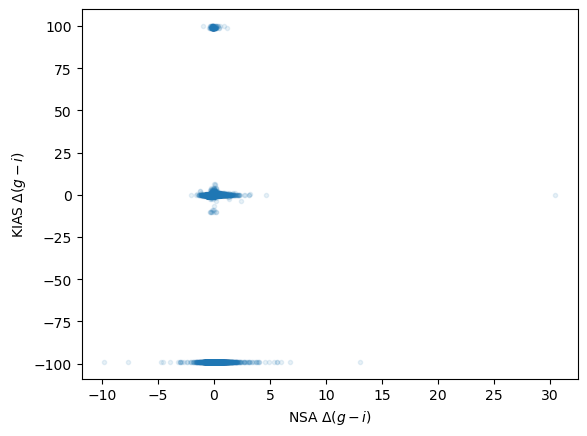

In [10]:
plt.scatter(nsa['NSA_cd'], nsa['kias_cd'], 
          alpha=0.1, marker='.', )
           # bins=100, 
           #range=[[-1, 1], [-5, 5]], 
           # norm=mpl.colors.LogNorm())
plt.xlabel(r'NSA $\Delta (g-i)$')
plt.ylabel(r'KIAS $\Delta (g-i)$')

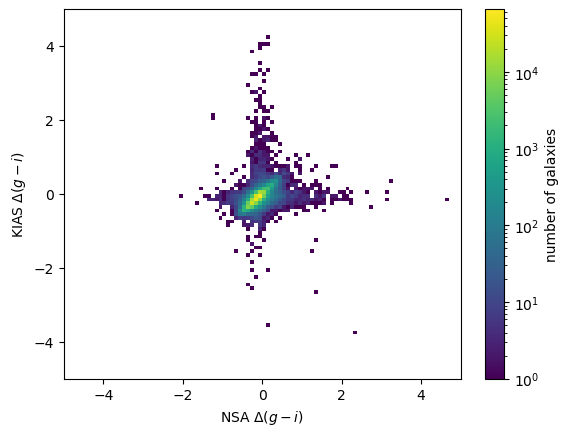

In [11]:
plt.hist2d(nsa['NSA_cd'], nsa['kias_cd'], 
          # alpha=0.1, marker='.', 
           bins=100, 
           range=[[-5, 5], [-5, 5]], 
           norm=mpl.colors.LogNorm())
plt.xlabel(r'NSA $\Delta (g-i)$')
plt.ylabel(r'KIAS $\Delta (g-i)$')
# plt.plot([-1,1],[-1,1], color='r', linewidth=2)
plt.colorbar(label='number of galaxies')

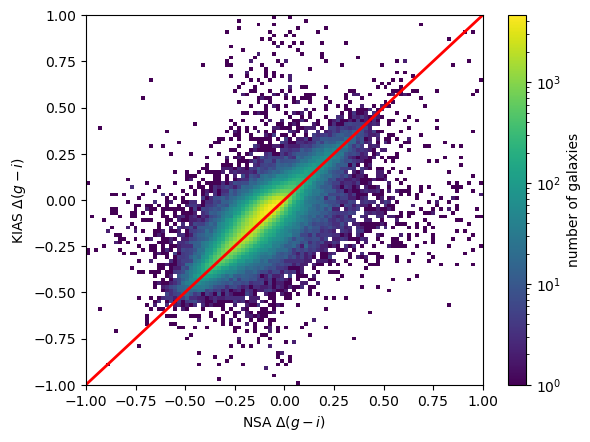

In [12]:
plt.hist2d(nsa['NSA_cd'], nsa['kias_cd'], 
          # alpha=0.1, marker='.', 
           bins=100, 
           range=[[-1, 1], [-1, 1]], 
           norm=mpl.colors.LogNorm())
plt.xlabel(r'NSA $\Delta (g-i)$')
plt.ylabel(r'KIAS $\Delta (g-i)$')
plt.plot([-1,1],[-1,1], color='r', linewidth=2)
plt.colorbar(label='number of galaxies')

In [13]:
nsa_highcd = nsa[nsa['NSA_cd'] > 2]
nsa_highcd[:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,g_mtot,g_m0,g_a1,g_a2,i_mtot,i_m0,i_a1,i_a2,NSA_cd,kias_cd
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J111658.75-002116.9,11h/m00/J111658.75-002116.9,169.2442811996919,-0.35708991575910326,4905,-1,-1,-1,-1,-1,17.492266,0.10308547,sdss,0.04469186,6793,3,58,301,659.2883,297.52524,4899,0.10244728,1.5231714 .. 5913.298,4.076846 .. 3.5888403e-05,1,4.8821163 .. 1585.1046,-16.539347 .. -24.50519,8.023673 .. 1064.5472,0.53801763 .. 0.0959865,0.98572433 .. -0.021134997,6.9199723e-06 .. 8e-45,7.971921e-05 .. 0.33693933,1.0306511e-09,0.48731118,0.025982415,36446960000.0,112.51477813720703,96.93658447265625,9 .. 3,0.011965024 .. 0.0,3415.812 .. 0.0,0.4172211 .. -0.4717883,-0.0030218514 .. 0.18063515,0.41120145 .. 0.32873908,-0.20748746 .. 79.52475,0.070057176 .. 689.69934,259.30188 .. 0.036656756,0.045376603 .. 612.25323,432.28152 .. 0.037000343,0.3447432,9.2948,0.011685649,0.54533386,0.9279867 .. 5616.104,11.126281 .. 0.0009494083,6.0,0.8764442,143.13882,0.0 .. 0.12611568,0.0 .. 0.0,24 .. 16,0,7,v2_1_13,0.22341923 .. 258.39,1.0207227,0.7280169,0.22341923,4.788161,279,150,51984,169.2448328364558,-0.35471794006850316,0.0,sdss,legacy,good,109,169.24482,-0.35466632,0.011685649,0.54533386,671.57227,0.04999101,15.89965,6.8760123,18.542938,15.89965,4.764212 .. 3148.2917,5.2819242 .. 0.0051232157,19.638357 .. 1.927141,28.534742 .. 11.467689,0.9970008,1.0770444 .. 0.99987096,1.0548813 .. 0.99921465,7.8198447 .. 3314.8936,1.6861734 .. 0.000116200215,1,8.792914 .. 1182.3115,-17.901026 .. -23.858973,87.46812 .. 1083.1721,0.57128024 .. -0.03895432,1.7131219e-12 .. 2.4077992e-06,24232262000.0,4.3107077e-05 .. 0.30530795,0.0362852,0.46714914,0.021155998,1.0,14.511768368418224,1.0773055708759596,0.017520002631240716,2.813579170517569,14.932412603983913,2.566563701336924,0.20292443996837886,1.2470005603944758,2.7735191441

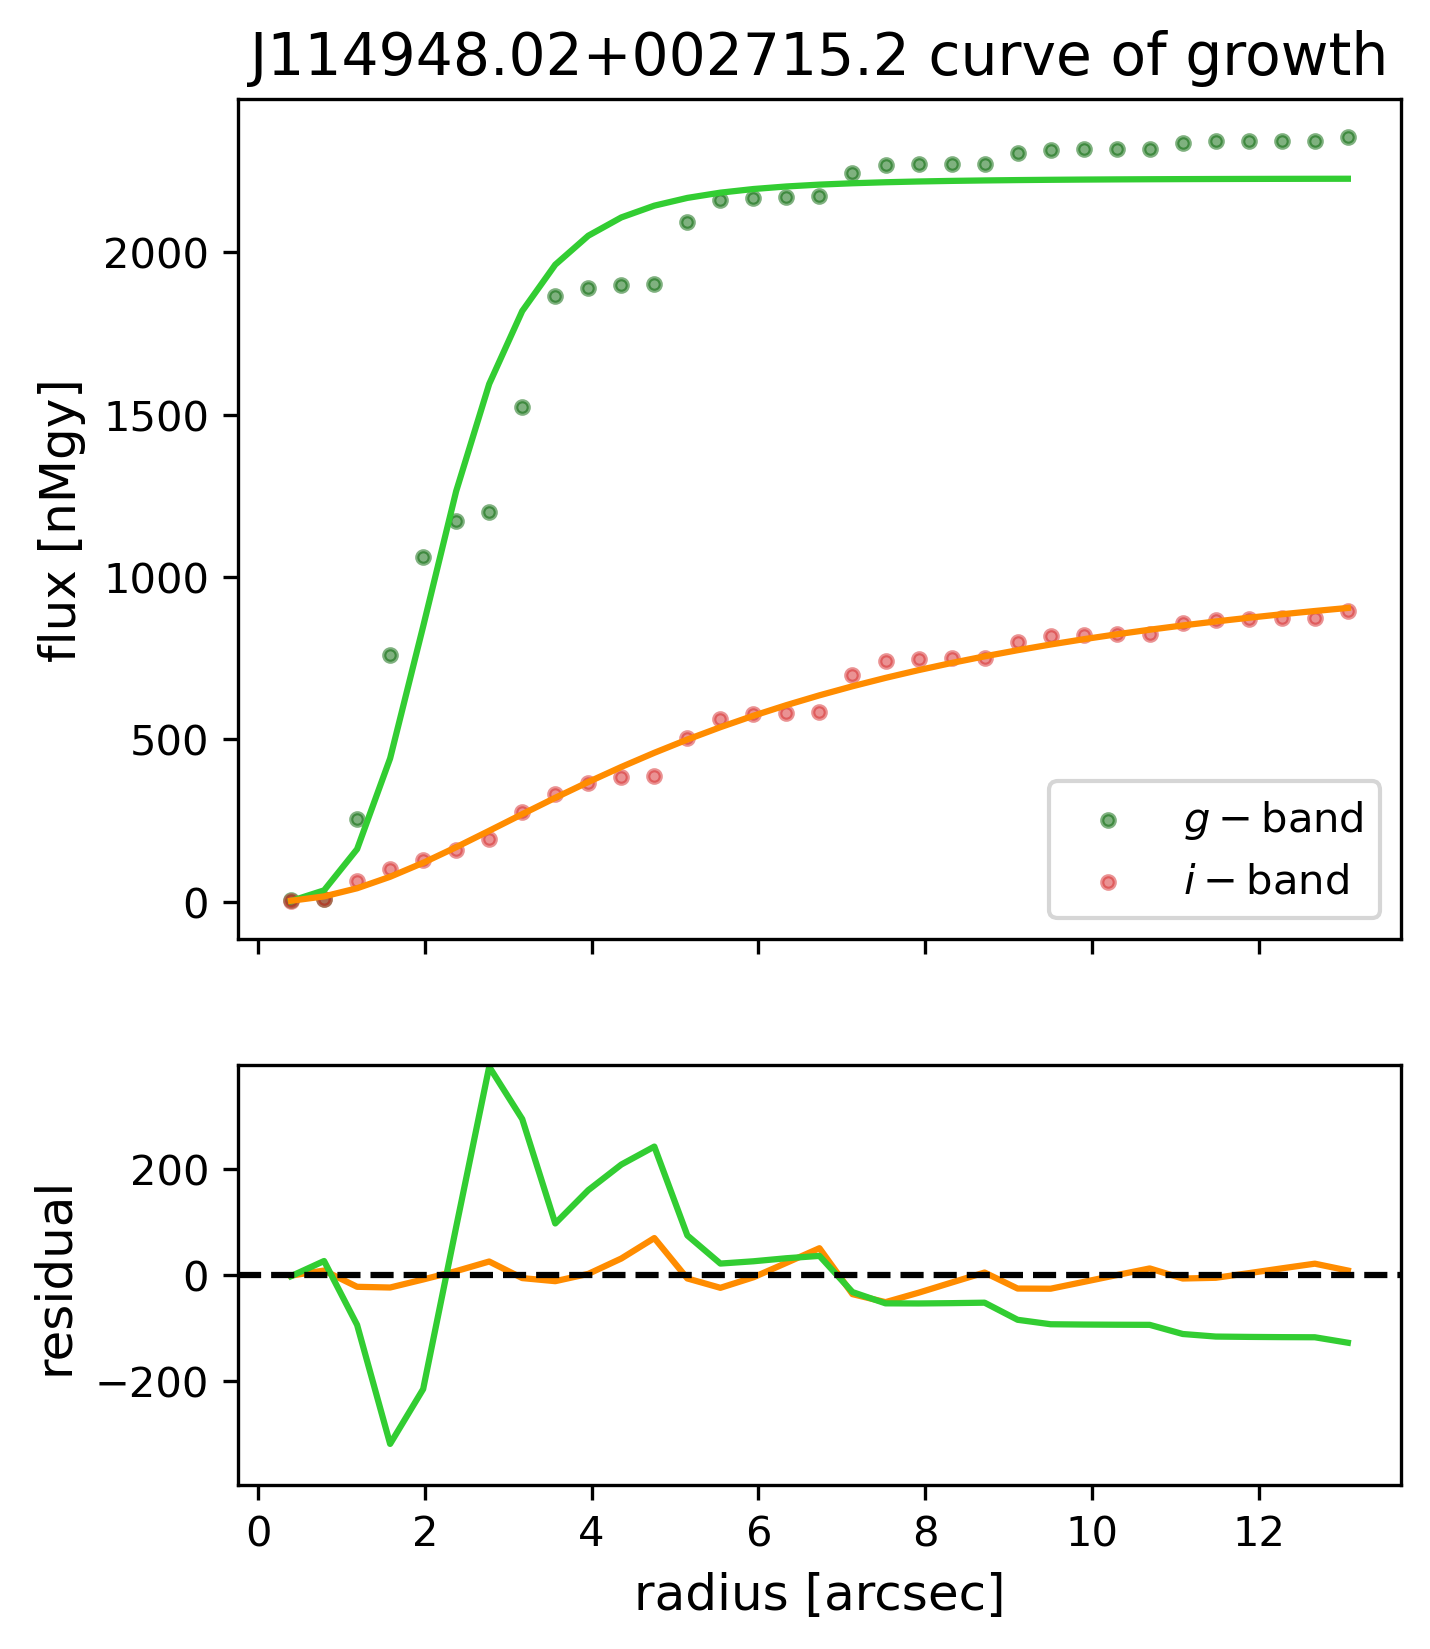

In [14]:
Image(DATA_FOLDER + '/cog_plots/' + str(nsa_highcd['IAUNAME'][1]) + '.png')

## should scale radius be a free param

In [15]:
SGA_2020_fn = '/global/cfs/cdirs/cosmo/data/sga/2020/SGA-2020.fits'
SGA_2020 = Table.read(SGA_2020_fn, hdu='ELLIPSE')
SGA_2020[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32
2,SGA-2020 2,PGC1283207,1283207,228.3770865,5.4232017,S?,152.2,0.36307806,0.724436,0.03463229,23.40448,16.976,False,LEDA-20181114,0,PGC1283207,1,True,228.3770865,5.4232017,0.36307806,2283p055,228.3770803831908,5.423191398593787,0.49470574,SB26,158.20142,0.545691,228.37700918822188,5.4232652570544015,10.897086,3.3509698,3.1147978,3.240862,5.902337,6.9126143,7.941369,8.997992,10.073601,11.199986,12.391357,13.561038,14.841172,16.966799,16.108246,15.486356,16.879545,16.024958,15.400715,16.818878,15.967034,15.341793,16.776297,15.925804,15.300776,16.746685,15.897334,15.272053,16.725166,15.876816,15.2521105,16.708357,15.862035,15.237181,16.696539,15.851936,15.226998,16.689613,15.844313,15.21976,0.013392451,0.02354,0.021872982,0.01736985,0.024445537,0.039866067,0.05026544,0.08455789,0.122911856,0.005682776,0.0054258136,0.0049038026,0.005588406,0.005323561,0.0047632363,0.00543534,0.005177031,0.0046343105,0.0053025587,0.005040888,0.0045181247,0.005206092,0.0049438984,0.0044374703,0.0051483097,0.0048758644,0.0043834248,0.0051032505,0.0048264163,0.004344248,0.0050705094,0.004792021,0.004319857,0.005054293,0.004765629,0.0043044444,16.65942,0.34037337,0.2978292,3.0239506,0.07928849,15.820566,0.2640441,0.34559453,3.3033552,0.003811298,15.195567,0.29826432,0.3001073,3.2333765,0.011723555,0
3,SGA-2020 3,PGC1310416,1310416,202.54443750000002,6.9345944,Sc,159.26,0.4017908,0.7816278,0.073888786,23.498482,16.85,False,LEDA-20181114,1,PGC1310416,1,True,202.54443750000002,6.9345944,0.4017908,

(array([2.8890e+03, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 7.2110e+03,
        3.9753e+04, 5.9526e+04, 5.7320e+04, 4.4602e+04, 2.4103e+04,
        1.5332e+04, 8.6200e+03, 4.0530e+03, 2.0820e+03, 1.0400e+03,
        5.5700e+02, 2.6100e+02, 1.3200e+02, 8.0000e+01, 5.4000e+01,
        2.6000e+01, 1.6000e+01, 1.3000e+01, 1.3000e+01, 3.0000e+00,
        3.0000e+00, 3.0000e+00, 1.0000e+00, 7.00

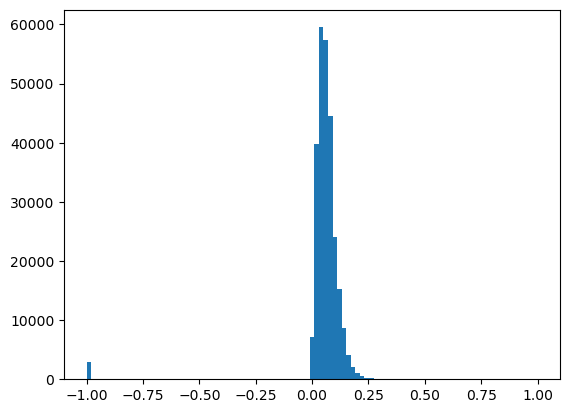

In [22]:
plt.hist(SGA_2020['Z_LEDA'][SGA_2020['Z_LEDA'] > -99], bins=np.linspace(-1,1,100))

(array([  7729.,  31106.,  55248.,  64073.,  81723., 101142.,  78702.,
         81639.,  74686.,  65361.]),
 array([-0.00448154,  0.01096657,  0.02641468,  0.04186279,  0.0573109 ,
         0.07275901,  0.08820712,  0.10365523,  0.11910334,  0.13455145,
         0.14999956]),
 <BarContainer object of 10 artists>)

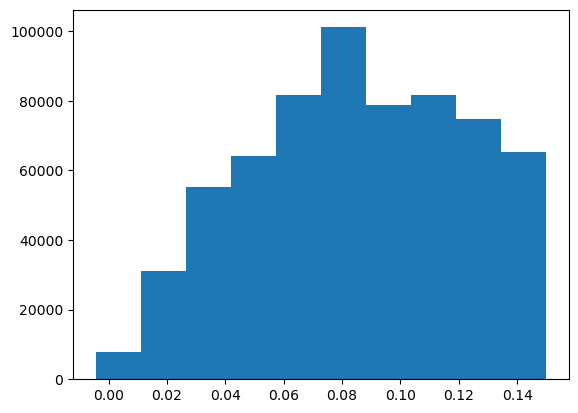

In [24]:
plt.hist(nsa['Z'])